In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from keras.datasets import mnist
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

2025-06-19 18:20:36.590252: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750357236.817110      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750357236.882970      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
def load_idx_images(filename):
    with open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_idx_labels(filename):
    with open(filename, 'rb') as f:
        labels = np.frombuffer(f.read(), np.uint8, offset=8)
    return labels

x_train = load_idx_images('/kaggle/input/mnist-dataset/train-images.idx3-ubyte')
y_train = load_idx_labels('/kaggle/input/mnist-dataset/train-labels.idx1-ubyte')
x_test = load_idx_images('/kaggle/input/mnist-dataset/t10k-images.idx3-ubyte')
y_test = load_idx_labels('/kaggle/input/mnist-dataset/t10k-labels.idx1-ubyte')

Downloads and splits MNIST dataset into:

x_train: training images, shape [60000, 28, 28]

y_train: training labels, shape [60000]

x_test: test images, shape [10000, 28, 28]

y_test: test labels, shape [10000]


In [3]:
# Normalize and convert to tensors
x_train_tensor = torch.tensor(x_train / 255.0, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
x_test_tensor = torch.tensor(x_test / 255.0, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

Divide by 255.0: Converts pixel values from [0–255] → [0–1] (normalization).

Convert all arrays into PyTorch tensors:

float32 for image tensors (required by neural nets)

long (int64) for label tensors (required by CrossEntropyLoss)

In [4]:
# 2. Create TensorDataset and DataLoader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

creating batch size with = 64

In [5]:
# 3. Model definition
model = nn.Sequential(
    nn.Flatten(),               # [batch_size, 28, 28] → [batch_size, 784]
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)           # Output logits (no softmax)
)


In [6]:
# 4. Loss and optimizer
criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Loss Function: CrossEntropyLoss

Internally applies LogSoftmax + NLLLoss

Works with raw logits (output of the last linear layer)

Labels must be LongTensor

Optimizer: Adam optimizer with learning rate 0.001

Adds a batch dimension to both image and label to make them compatible with the model.

Model expects [batch_size, 28, 28] → Flattened to [batch_size, 784]

label must be [batch_size] for CrossEntropyLoss.

In [7]:
# 5. Training loop
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:              # Now we use batches
        output = model(images)                       # Shape: images = [batch_size, 28, 28], label = [batch_size, 1]
        loss = criteria(output, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Training loss: {running_loss / len(train_loader):.4f}")

Epoch 1, Training loss: 0.3560
Epoch 2, Training loss: 0.1521
Epoch 3, Training loss: 0.1027
Epoch 4, Training loss: 0.0768
Epoch 5, Training loss: 0.0588


In [ ]:
# 6. Testing
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0) 

print(f"Test Accuracy: {100 * correct / total:.2f}%")
print(f'correct : {correct}, total : {total}')

Test Accuracy: 97.35%
correct : 9735, total : 10000


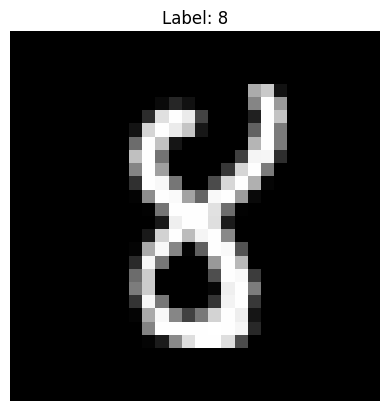

tensor([[ -3.7226,  -5.8560,  -5.3792,  -2.6331,  -1.2990,  -0.2683,  -1.3043,
         -10.0080,   8.3320,  -1.6403]], grad_fn=<AddmmBackward0>)
Predicted digit: 8


In [9]:
#testing one by one , raw testing
import matplotlib.pyplot as plt

# Choose the image and convert it to NumPy for plotting
input = 5656
image = x_test_tensor[input].numpy()

# Plot the image
plt.imshow(image, cmap='gray')
plt.title(f"Label: {y_test_tensor[input].item()}")
plt.axis('off')
plt.show()

output = model(x_test_tensor[input].unsqueeze(0))  # [28, 28] - > [1, 28, 28]
print(output) 
predicted_digit = torch.argmax(output, dim=1).item()
print(f"Predicted digit: {predicted_digit}")